# From Stray to Stay: Leveraging Data to Improve Pet Adoption and Shelter Efficiency

## Project Overview
**Client:** Austin Animal Center — the largest no-kill municipal animal shelter in the United States, serving Austin, TX and surrounding Travis County.

Business Problem: The shelter operates under a no-kill mandate with constrained resources and rising intake volumes. Leadership needs data-driven insight into three core operational questions:

1. Are there seasonal or geographic patterns in intake that would support proactive capacity planning?
2. Which animal characteristics correlate with longer stays or repeat shelter returns — and what interventions might help?
3. Has shelter performance (adoption rate, live release rate) improved over time, and where do operational bottlenecks remain?

**Motivation:** As pet companionship becomes increasingly central to household life, shelter intake volumes continue to grow. Data-driven planning offers a path toward better resource allocation, more effective adoption outreach, and more equitable outcomes across animal types.

**Tools:** Google BigQuery (SQL-based ETL and analysis), Tableau Public (interactive dashboards), Jupyter Notebook (documentation and workflow).

## Data Source

Austin Animal Center Outcomes (10/01/2013 to 05/05/2025)

https://data.austintexas.gov/Health-and-Community-Services/Austin-Animal-Center-Outcomes-10-01-2013-to-05-05-/9t4d-g238/about_data

Austin Animal Center Intakes (10/01/2013 to 05/05/2025)


https://data.austintexas.gov/Health-and-Community-Services/Austin-Animal-Center-Intakes-10-01-2013-to-05-05-2/wter-evkm/about_data

Our datasets come from the Austin Open Data Portal. Each original dataset contains approximately 174,000 rows and 12 columns, with a total size of about 30 MB. We used this publicly available data to create three linked tables from the Austin Open Data Portal — Intake records, Outcome records, and a parsed geographic table derived from Found Location fields.

**License:** Public Domain  
**Source:** http://www.austintexas.gov/department/animal-services

## Executive Summary

This analysis examines five years of Austin Animal Center intake and outcome records (2020–2025), covering approximately 60,000 intake events and 60,000 corresponding outcomes. The Austin Animal Center is the largest no-kill municipal shelter in the United States, and this dataset reflects its performance through COVID recovery, post-pandemic growth, and current operations.



### Key Findings

*   Intake volumes exhibit a consistent seasonal pattern, peaking in Spring with a significant increase of 21% compared to the Winter baseline. This surge in intake volumes is mirrored by a corresponding surge in Summer, indicating a strong community engagement during warmer months.

*   Annual net flow between intakes and outcomes stays within ±200 events per year across the full study period, indicating the shelter maintains near-perfect throughput balance.

*   Dogs re-enter the shelter at 9.8% vs. 3.2% for cats — a 3x gap that signals post-adoption instability and points toward a need for targeted follow-up support for dog adopters.

*   The overall adoption rate improved from 50% in 2020 to 63% in 2024, a 13-percentage-point gain over four years.

*   Stray intakes (primarily along major traffic corridors such as Levander Loop and IH-35) dominate volume, suggesting that community-level interventions, including microchipping, trap-neuter-return (TNR), and targeted outreach, would address root causes more effectively than shelter-side adjustments alone.

*   Animal color significantly influences adoption likelihood; patterned and lighter-coated animals show higher adoption rates, with practical implications for listing photography and featured-animal programs.

## Tableau Dashboards

* https://public.tableau.com/app/profile/yuyang.zhai6198/viz/TeamA02/dataoverview

* https://public.tableau.com/app/profile/yuyang.zhai6198/viz/TeamA02-dashboard2/IntakeOutcomeBehaviorAnalytics

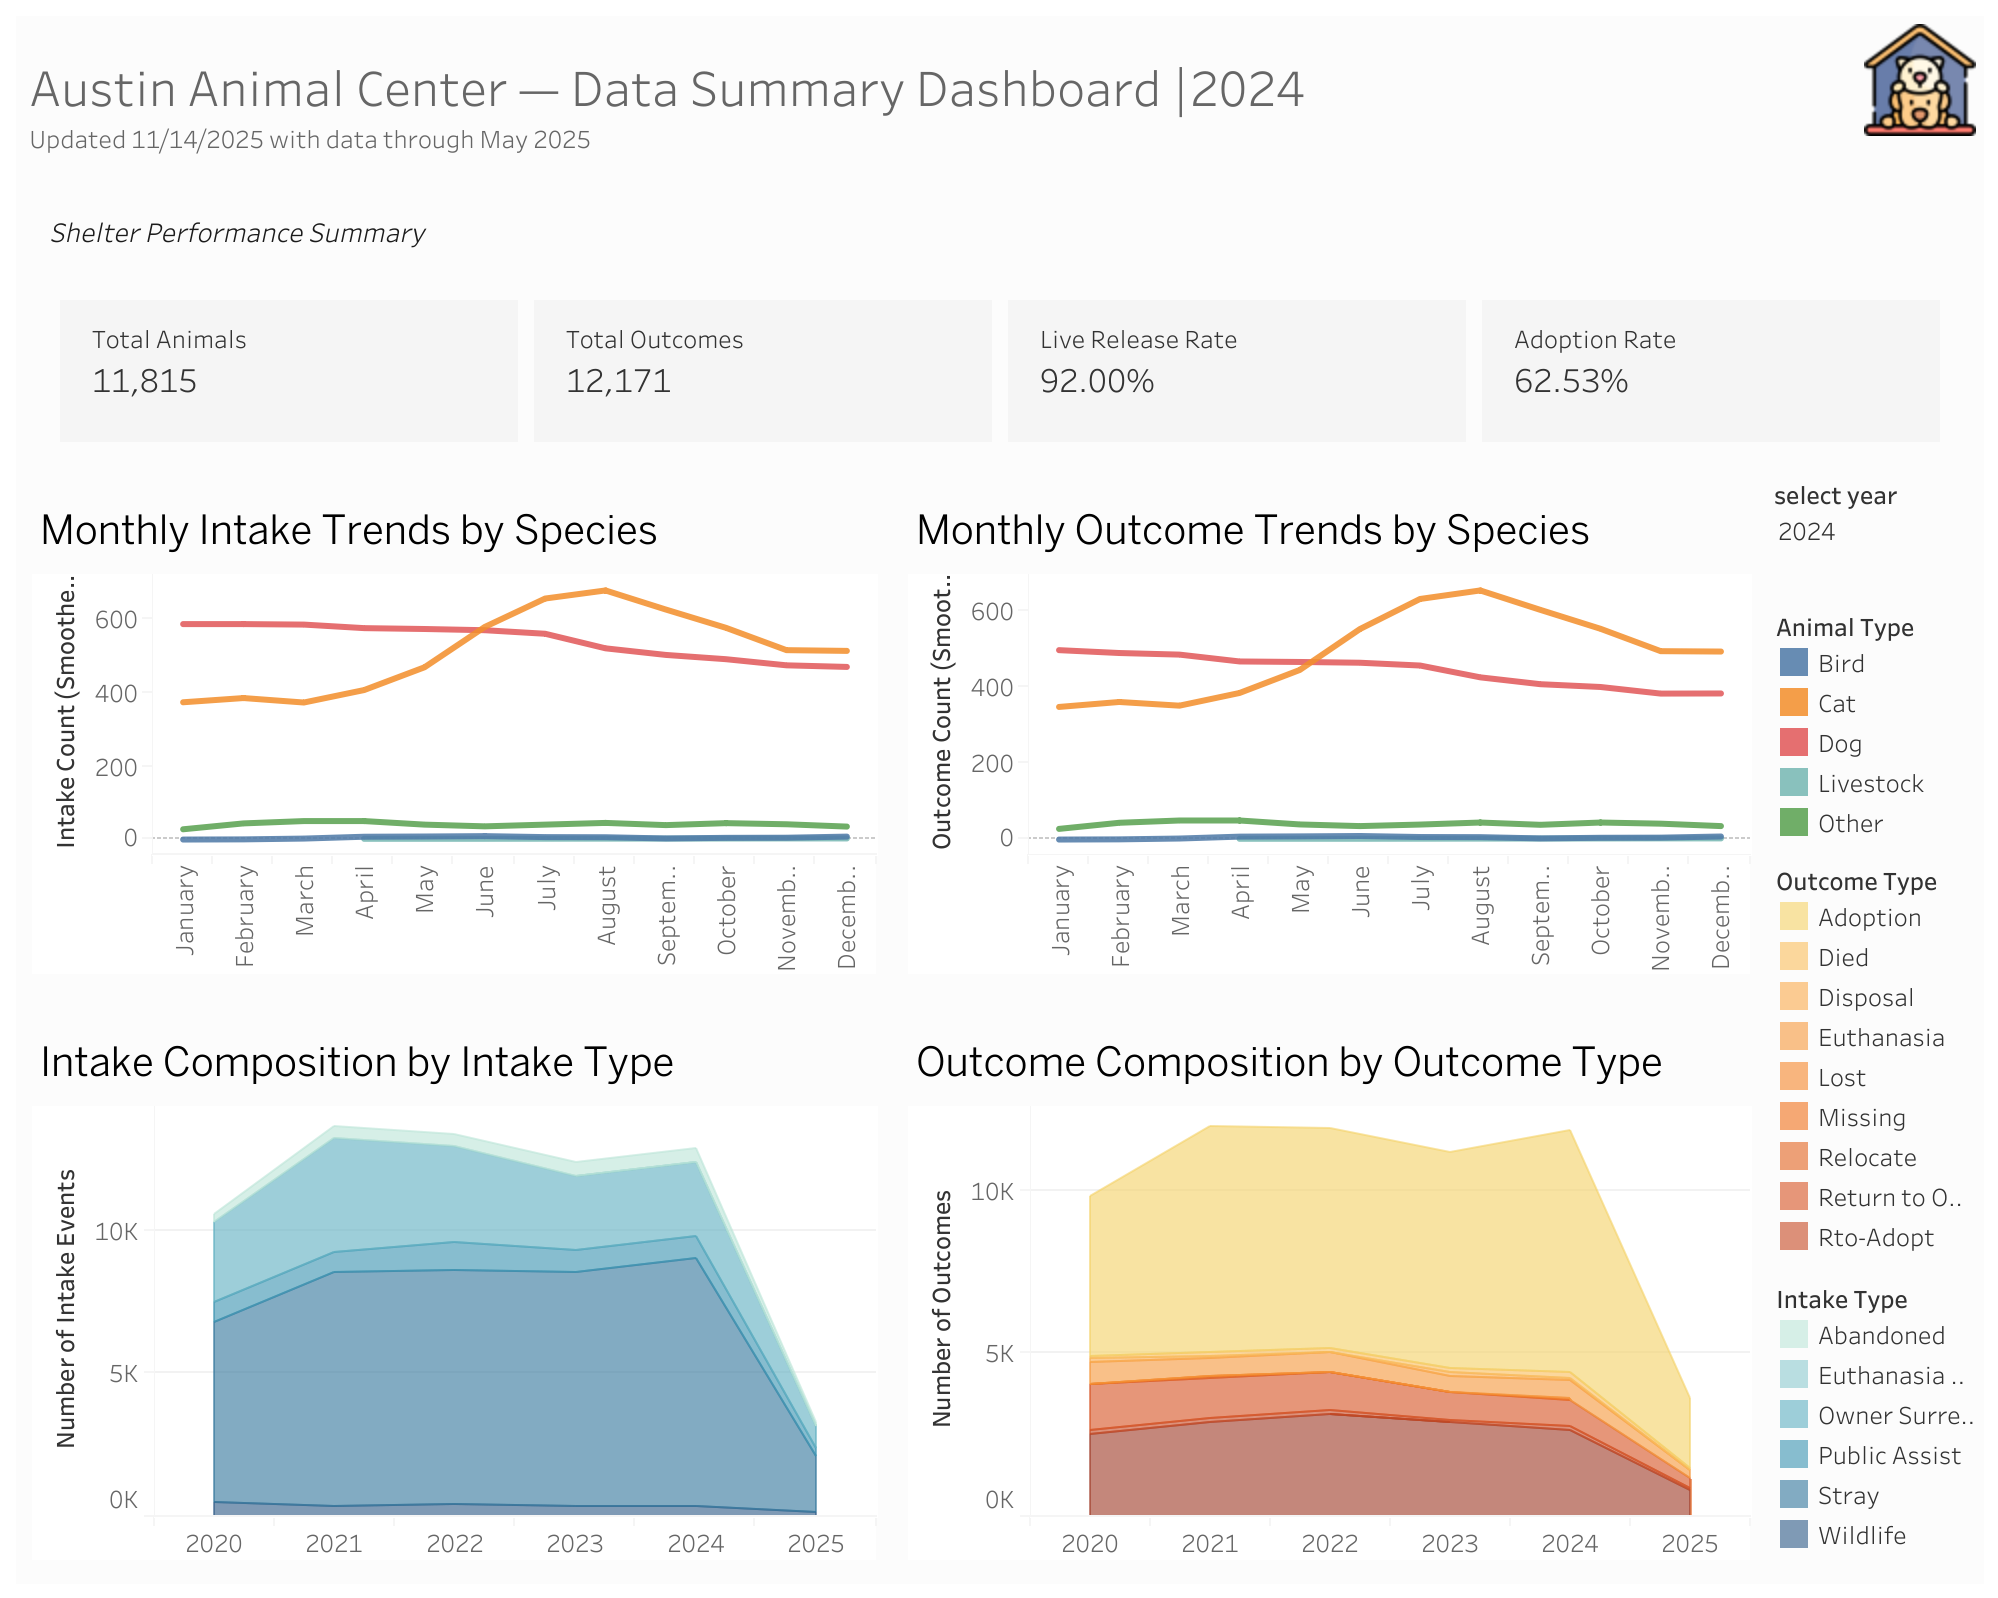

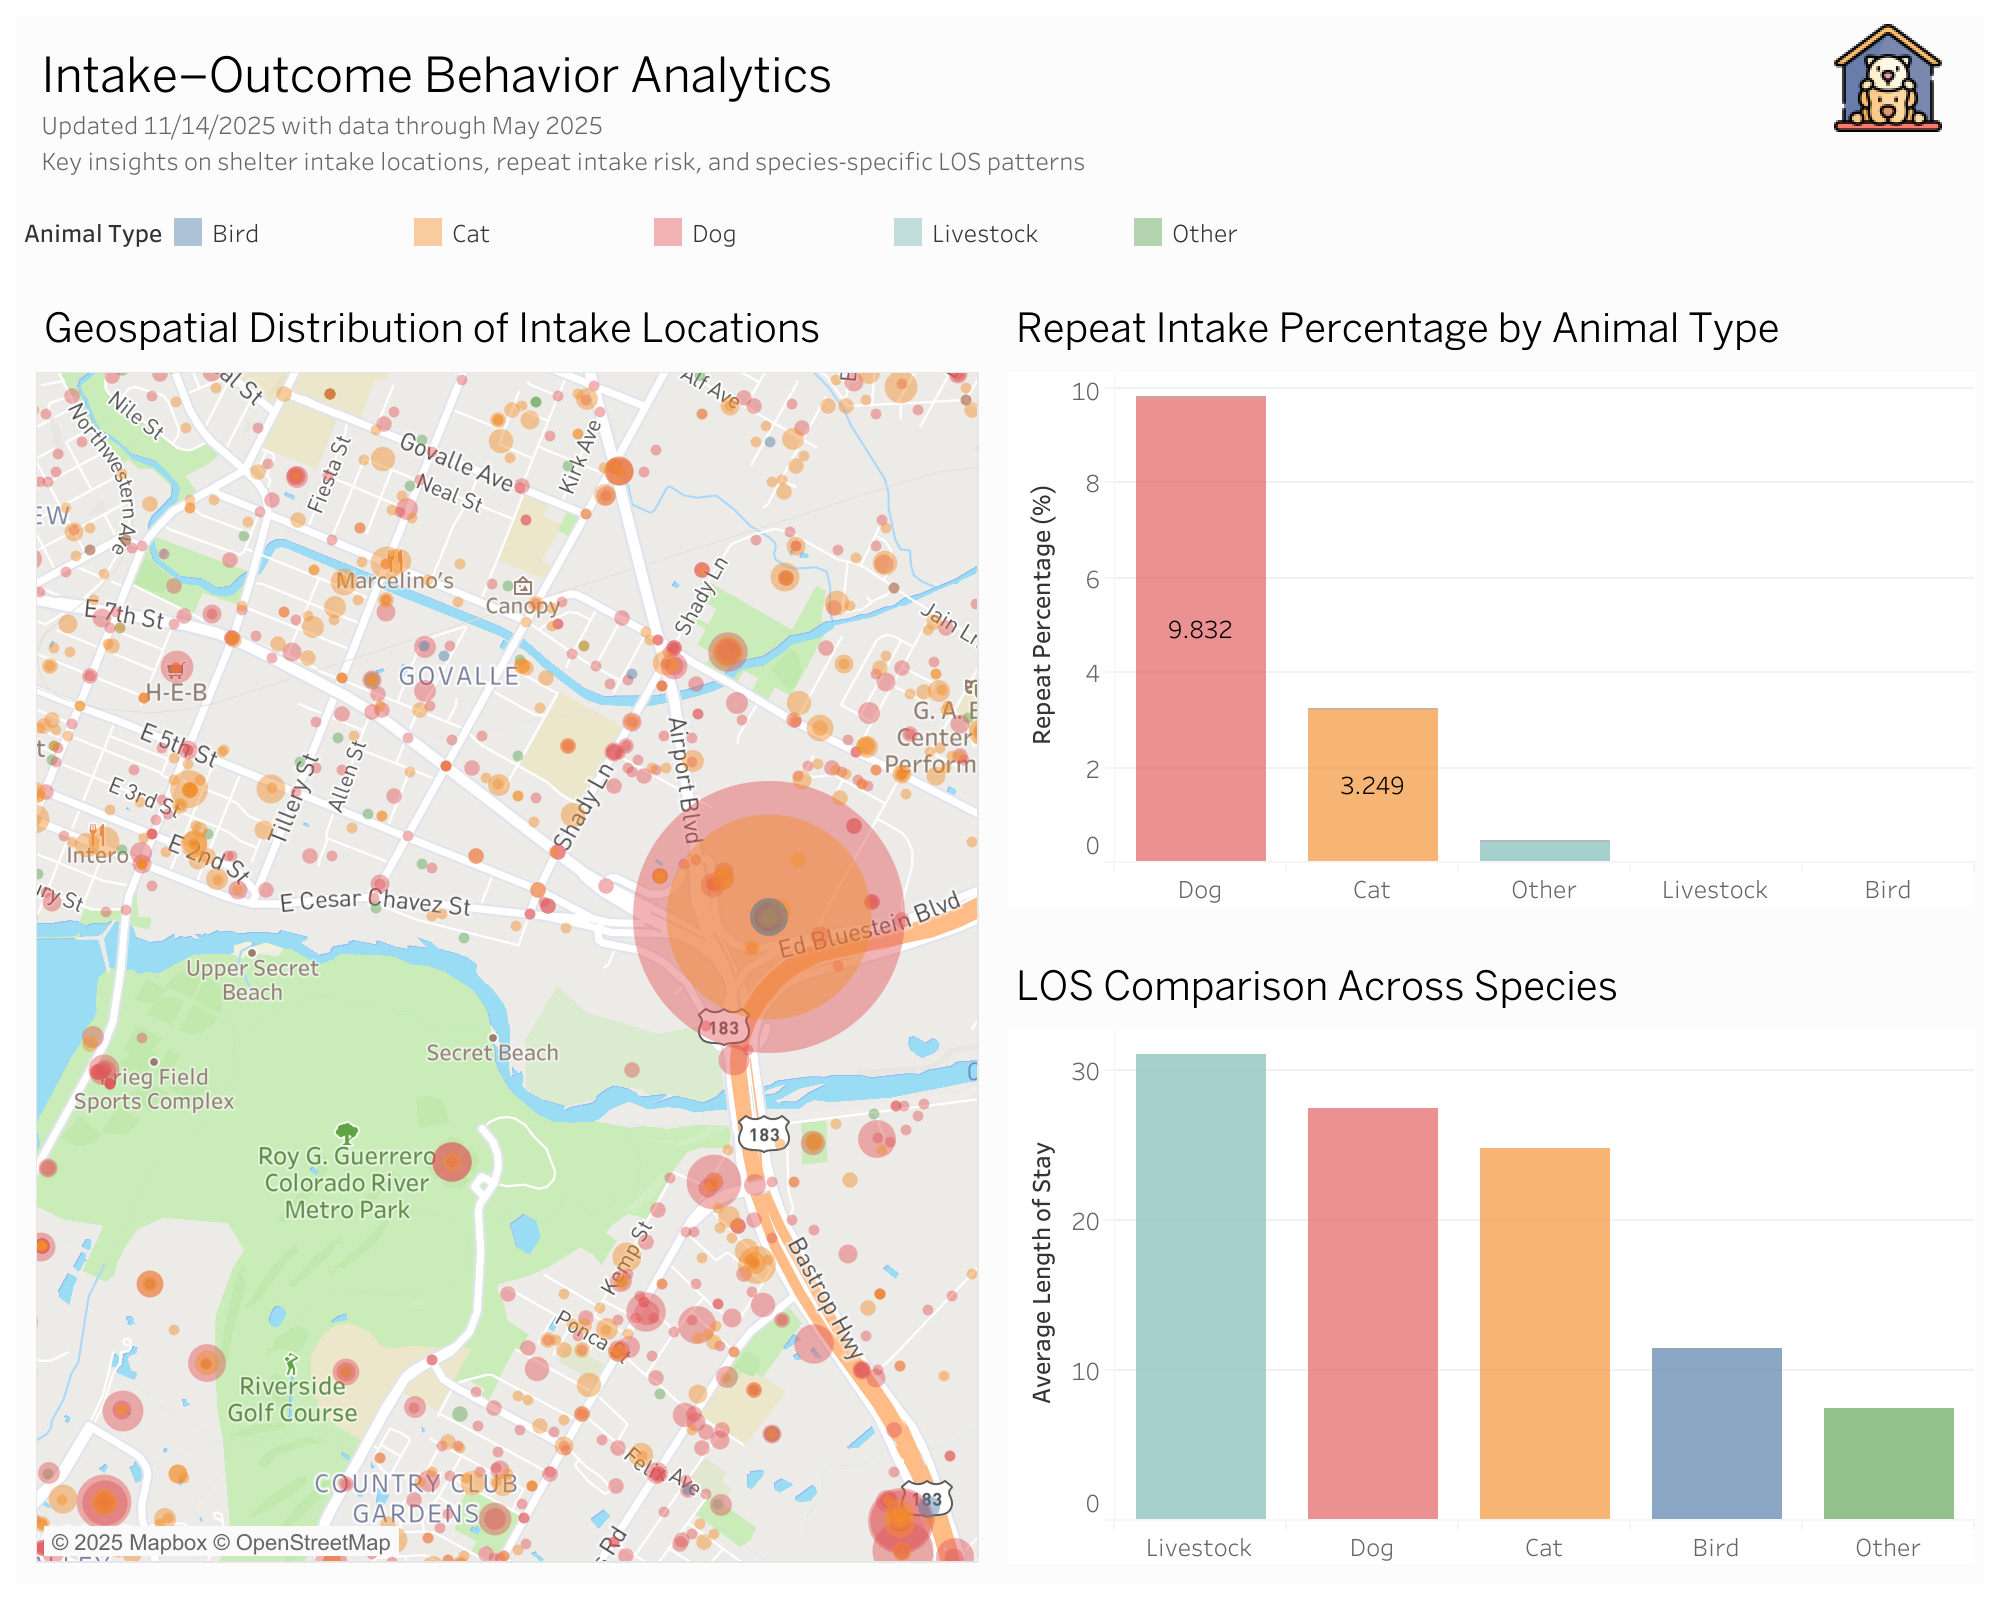

## Entity Relationship Diagram + Data Dictionaries

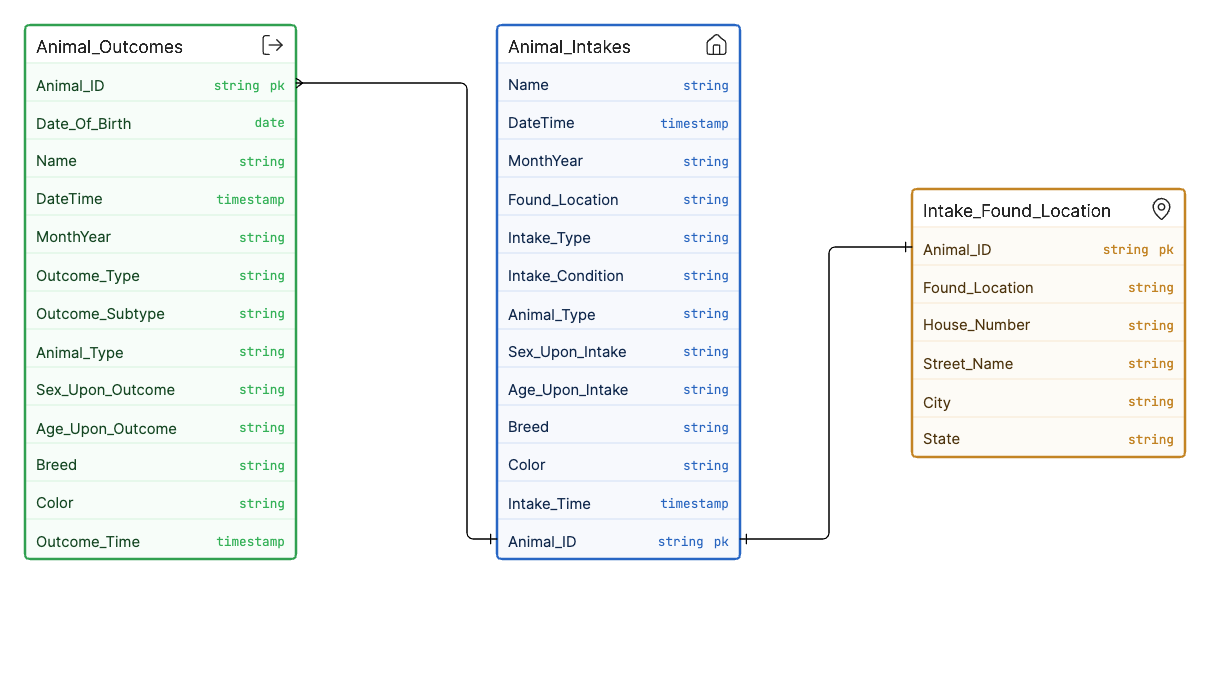

Relationship lines denote one-to-many (Intakes → Outcomes) and one-to-one (Intakes → Found Location) via Animal_ID.

Animal Intake Location Data Dictionary
<div style="font-size: 14px;">

| **Column Name**      | **Description**                                                 | **Data Type** |
| -------------------- | --------------------------------------------------------------- | ------------- |
| **Animal ID**        | Unique identifier assigned to each animal                       | String        |
| **Name**             | Name of the animal, if known                                    | String        |
| **DateTime**         | Exact date and time the animal entered the shelter              | Timestamp     |
| **MonthYear**        | Month-year value derived from DateTime                          | String        |
| **Found Location**   | Location where the animal was found                             | String        |
| **Intake Type**      | Reason or category of intake (e.g., Stray, Owner Surrender)     | String        |
| **Intake Condition** | Condition of the animal at intake (e.g., Normal, Sick, Injured) | String        |
| **Animal Type**      | Species classification (Dog, Cat, etc.)                         | String        |
| **Sex upon Intake**  | Sex and reproductive status at intake                           | String        |
| **Age upon Intake**  | Estimated age at intake                                         | String        |
| **Breed**            | Recorded breed(s) of the animal                                 | String        |
| **Color**            | Color description of the animal                                 | String        |
| **Intake Time**            | Exact date and time the animal entered the shelter(Cleaned)                                 | Timestamp        |


Animal Outcome Location Data Dictionary
<div style="font-size: 14px;">

| **Column Name**      | **Description**                                                 | **Data Type** |
| -------------------- | --------------------------------------------------------------- | ------------- |
| **Animal ID**        | Unique identifier matching intake records                       | String        |
| **Date of Birth**    | Birth date of the animal, if known                              | Date          |
| **Name**             | Name of the animal                                              | String        |
| **DateTime**         | Exact date and time the animal left the shelter                 | Timestamp     |
| **MonthYear**        | Month-year value derived from DateTime                          | String        |
| **Outcome Type**     | Category of outcome (Adoption, Transfer, Return to Owner, etc.) | String        |
| **Outcome Subtype**  | Additional detail about outcome                                 | String        |
| **Animal Type**      | Species classification                                          | String        |
| **Sex upon Outcome** | Sex and reproductive status at outcome                          | String        |
| **Age upon Outcome** | Estimated age at outcome                                        | String        |
| **Breed**            | Recorded breed(s)                                               | String        |
| **Color**            | Color description                                               | String        |
| **Outcome Time**            | Exact date and time the animal left the shelter(Cleaned)                                 | Timestamp        |


Intake Found Location Data Dictionary
<div style="font-size: 14px;">

| **Column Name**      | **Description**                                         | **Data Type**  |
|----------------------|---------------------------------------------------------|----------------|
| **Animal ID**         | Unique identifier assigned to each animal               | STRING         |
| **house_number**      | House number of the animal's found location             | STRING         |
| **street_name**       | Street name where the animal was found                  | STRING         |
| **city**              | City where the animal was found                         | STRING         |
| **state**             | State where the animal was found                        | STRING         |
</div>


In [ ]:
from google.cloud import bigquery
client = bigquery.Client()    # BigQuery authentication and client setup

from google.colab import auth
auth.authenticate_user()

## Data Preparation: Building a Reliable Analytical Foundation

The table below summarizes each data quality issue identified, the transformation applied, and the justification for each decision.

| **Column**                             | **Issue Identified**                                           | **Action (SQL Transformation)**                                                               | **Justification**                                                                                  |
| -------------------------------------- | -------------------------------------------------------------- | --------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------- |
| **DateTime (Intake & Outcome)**        | Some timestamps had invalid years recorded as `00xx`           | `REGEXP_REPLACE(CAST(DateTime AS STRING), r'^00(\d{2})', r'20\1')` + `SAFE.PARSE_TIMESTAMP()` | Ensures timestamps are valid and allows accurate temporal analysis for trends and LOS.             |
| **Full Record (All Columns)**          | Presence of exact duplicate rows                               | `SELECT DISTINCT *` when creating `*_2020_2025_clean` tables                                  | Removes erroneous duplication while preserving correct multiple-intake events for the same animal. |
| **Age upon Intake / Age upon Outcome** | Negative ages and potential invalid formats                    | `WHERE NOT (Age LIKE '-%')` and regex validation checks                                       | Eliminates biologically impossible values and ensures age-related modeling is credible.            |
| **Found Location**                     | Unstructured, inconsistent address strings                     | `REGEXP_EXTRACT()` to derive `house_number`, `street_name`, `city`, `state`                   | Converts messy text into structured geographic features, enabling mapping and hotspot analysis.    |
| **Analysis Window (All Columns)**      | Dataset spans 2013–2025; analysis needs a consistent timeframe | `EXTRACT(YEAR FROM Intake_Time) BETWEEN 2020 AND 2025`                                        | Focuses on recent, more relevant data and avoids noise from legacy records.                        |
| **Outcome Matching (Animal ID)**       | Some intake records not matched to outcomes                    | `LEFT JOIN` + count comparison                                                                | Verifies data completeness and confirms dataset integrity (98.4% match rate).                      |
| **Animal Name**                        | Missing values                                                 | Accepted as-is (no SQL operation)                                                             | Name does not impact modeling or analysis, so no imputation needed.                                |



Before cleaning, the dataset contained inconsistent timestamps (including *00xx* years), unstructured address formats, exact duplicate rows mixed with valid repeat-intake events, and a small number of invalid age values. After applying regex-based timestamp repair, structured address extraction, duplicate removal, and age validation, the data is now standardized, accurate, and analysis-ready. These improvements enable reliable temporal trends, geographic insights, and outcome modeling across the 2020–2025 period.

### What Does the Raw Dataset Look Like?

Before scoping the analysis window, we first inspect the raw intake table to understand its structure, field types, and a sample of records.

In [ ]:
%%bigquery --project ba775-team2-project
SELECT *
FROM `ba775-team2-project.Austin_Animal_Center_Data.Intake_2013_2025_Period`
LIMIT 5


Query is running:   0%|          |

Downloading:   0%|          |

,Animal ID,Name,DateTime,MonthYear,Found Location,Intake Type,Intake Condition,Animal Type,Sex upon Intake,Age upon Intake,Breed,Color
0,A795857,None,2019-05-25 13:43:00+00:00,May-19,202 North Lake Hills Drive in Austin (TX),Stray,Normal,Cat,Intact Female,1 month,Abyssinian,Torbie/White
1,A795859,None,2019-05-25 13:43:00+00:00,May-19,202 North Lake Hills Drive in Austin (TX),Stray,Normal,Cat,Intact Female,1 month,Abyssinian,Torbie
2,A798848,None,2019-07-01 13:05:00+00:00,Jul-19,13301 Dearbonne Drive in Travis (TX),Stray,Normal,Cat,Intact Female,1 year,Abyssinian,Torbie
3,A800187,None,2019-07-17 13:47:00+00:00,Jul-19,1101 Brodie Street in Austin (TX),Stray,Normal,Cat,Unknown,1 year,Abyssinian,Brown
4,A800331,None,2019-07-19 13:26:00+00:00,Jul-19,8505 Mayview Drive in Austin (TX),Stray,Normal,Cat,Intact Female,1 year,Abyssinian,Brown Tabby


### Why 2020–2025? Scoping the Analysis Window

The full dataset spans 2013–2025, but the analysis focuses on the five most recent complete years (2020–2025) for two reasons. First, shelter operations and community practices evolve over time; older data may reflect policies or conditions no longer relevant. Second, this window captures a meaningful operational arc: the COVID disruption of 2020, the post-pandemic recovery, and current steady-state performance. Approximately 60,000 intake records fall within this time frame, providing a substantial dataset for analyzing trends and segments effectively.

Note: We also noticed that some older timestamps were recorded as `00xx` (e.g., `0019-05-03`). To rectify this, we employed a regular expression to automatically replace `00xx` with `20xx`.

In [ ]:
%%bigquery --project ba775-team2-project

CREATE OR REPLACE TABLE
 `ba775-team2-project.Austin_Animal_Center_Data.intake_2020_2025` AS


SELECT
 *
FROM (
 SELECT
   *,
   COALESCE(
     SAFE.PARSE_TIMESTAMP(
       '%Y-%m-%d %H:%M:%S%Ez',
       REGEXP_REPLACE(CAST(DateTime AS STRING), r'^00(\d{2})', r'20\1')
     ),
     SAFE.PARSE_TIMESTAMP(
       '%Y-%m-%d %H:%M:%S',
       REGEXP_REPLACE(CAST(DateTime AS STRING), r'^00(\d{2})', r'20\1')
     )
   ) AS Intake_Time
 FROM
   `ba775-team2-project.Austin_Animal_Center_Data.Intake_2013_2025_Period`
)
WHERE
 EXTRACT(YEAR FROM Intake_Time) BETWEEN 2020 AND 2025;

Query is running:   0%|          |

""


### Assessing Data Completeness

The only missing field is animal name, absent for roughly 24% of intake records. This is expected because many stray animals arrive without names or with names left blank by field staff. Since names are not used in any analytical calculations, this gap does not affect the integrity of any downstream findings. All other fields, including Animal ID, DateTime, intake type, species, breed, color, age, and condition, are complete, providing a solid foundation for analysis.

In [ ]:
%%bigquery --project ba775-team2-project
SELECT
  SUM(CASE WHEN `Animal ID` IS NULL THEN 1 ELSE 0 END) AS missing_animal_id,
  SUM(CASE WHEN Name IS NULL THEN 1 ELSE 0 END) AS missing_name,
  SUM(CASE WHEN DateTime IS NULL THEN 1 ELSE 0 END) AS missing_datetime,
  SUM(CASE WHEN `Found Location` IS NULL THEN 1 ELSE 0 END) AS missing_location,
  SUM(CASE WHEN `Intake Type` IS NULL THEN 1 ELSE 0 END) AS missing_intake_type,
  SUM(CASE WHEN `Intake Condition` IS NULL THEN 1 ELSE 0 END) AS missing_condition,
  SUM(CASE WHEN `Animal Type` IS NULL THEN 1 ELSE 0 END) AS missing_animal_type,
  SUM(CASE WHEN `Sex upon Intake` IS NULL THEN 1 ELSE 0 END) AS missing_sex,
  SUM(CASE WHEN `Age upon Intake` IS NULL THEN 1 ELSE 0 END) AS missing_age,
  SUM(CASE WHEN Breed IS NULL THEN 1 ELSE 0 END) AS missing_breed,
  SUM(CASE WHEN Color IS NULL THEN 1 ELSE 0 END) AS missing_color
FROM `ba775-team2-project.Austin_Animal_Center_Data.intake_2020_2025`;


Query is running:   0%|          |

Downloading:   0%|          |

,missing_animal_id,missing_name,missing_datetime,missing_location,missing_intake_type,missing_condition,missing_animal_type,missing_sex,missing_age,missing_breed,missing_color
0,0,14665,0,0,0,0,0,0,0,0,0


### Distinguishing True Duplicates from Repeat Intake Events

The shelter's data model is event-based, not animal-based: each intake record represents a separate entry event, even for the same animal. This means animals with multiple rows are not data errors, they are genuine repeat entrants. The query below surfaces animals that appear more than once, allowing us to confirm that most apparent "duplicates" reflect real re-entry events rather than recording mistakes. True exact duplicates (identical across all fields) will be removed in the next step; valid repeat events are preserved.

In [ ]:
%%bigquery --project ba775-team2-project
with duplicate_case as (SELECT
 `Animal ID`,
 COUNT(*) AS occurrences
FROM
 `ba775-team2-project.Austin_Animal_Center_Data.intake_2020_2025`
GROUP BY
 `Animal ID`
HAVING
 COUNT(*) > 1
ORDER BY
 occurrences DESC)


select *
FROM `ba775-team2-project.Austin_Animal_Center_Data.intake_2020_2025`
INNER JOIN duplicate_case using (`Animal ID`)
limit 10

Query is running:   0%|          |

Downloading:   0%|          |

,Animal ID,Name,DateTime,MonthYear,Found Location,Intake Type,Intake Condition,Animal Type,Sex upon Intake,Age upon Intake,Breed,Color,Intake_Time,occurrences
0,A889917,Chip,2023-09-29 13:31:00+00:00,Sep-23,805 El Viejo Camino in Austin (TX),Stray,Normal,Cat,Intact Female,1 month,Abyssinian,Agouti,2023-09-29 13:31:00+00:00,2
1,A889917,Chip,2024-11-04 14:04:00+00:00,Nov-24,1714 E Parmer Lane in Austin (TX),Stray,Normal,Cat,Spayed Female,1 year,Abyssinian,Agouti,2024-11-04 14:04:00+00:00,2
2,A860247,Lincoln Aka Luke,2022-06-24 18:24:00+00:00,Jun-22,7101 North Ih 35 in Austin (TX),Public Assist,Normal,Dog,Intact Male,8 months,Affenpinscher Mix,Brown,2022-06-24 18:24:00+00:00,2
3,A860247,Lincoln Aka Luke,2022-10-28 12:58:00+00:00,Oct-22,Outside Jurisdiction,Owner Surrender,Normal,Dog,Neutered Male,1 year,Affenpinscher Mix,Brown,2022-10-28 12:58:00+00:00,2
4,A872036,Buddy,2023-08-09 15:33:00+00:00,Aug-23,Austin (TX),Owner Surrender,Normal,Dog,Neutered Male,2 years,Akbash Mix,White,2023-08-09 15:33:00+00:00,2
5,A872036,Buddy,2023-04-28 16:54:00+00:00,Apr-23,Grayledge Drive And Valley Forge Drive in Aust...,Stray,Normal,Dog,Neutered Male,2 years,Akbash Mix,White,2023-04-28 16:54:00+00:00,2
6,A821472,Sgt Amor Aka Sarge,2022-04-21 16:27:00+00:00,Apr-22,Austin (TX),Public Assist,Normal,Dog,Neutered Male,4 years,Akita,White,2022-04-21 16:27:00+00:00,2
7,A821472,Sgt Amor Aka Sarge,2022-05-05 15:08:00+00:00,May-22,Austin (TX),Public Assist,Normal,Dog,Neutered Male,4 years,Akita,White,2022-05-05 15:08:00+00:00,2
8,A823791,Luca,2020-10-20 15:14:00+00:00,Oct-20,Austin (TX),Owner Surrender,Injured,Dog,Neutered Male,1 year,Akita,Black/White,2020-10-20 15:14:00+00:00,3
9,A823791,Luca,2020-10-06 17:02:00+00:00,Oct-20,Austin (TX),Owner Surrender,Normal,Dog,Neutered Male,1 year,Akita,Black/White,2020-10-06 17:02:00+00:00,3


### Cleaning Step: Removing Exact Duplicates While Preserving Valid Repeat Events

In [ ]:
%%bigquery --project ba775-team2-project

-- Identify duplicates and create a cleaned version in one query
CREATE OR REPLACE TABLE `ba775-team2-project.Austin_Animal_Center_Data.intake_2020_2025_clean` AS
WITH duplicates AS (
  SELECT
    `Animal ID`,
    COUNT(*) AS duplicate_count
  FROM `ba775-team2-project.Austin_Animal_Center_Data.intake_2020_2025`
  GROUP BY
    `Animal ID`,
    `Name`,
    `DateTime`,
    `MonthYear`,
    `Found Location`,
    `Intake Type`,
    `Intake Condition`,
    `Animal Type`,
    `Sex upon Intake`,
    `Age upon Intake`,
    `Breed`,
    `Color`
  HAVING COUNT(*) > 1
)
SELECT DISTINCT *
FROM `ba775-team2-project.Austin_Animal_Center_Data.intake_2020_2025`;


Query is running:   0%|          |

""


In [ ]:
%%bigquery --project ba775-team2-project
SELECT *
from `ba775-team2-project.Austin_Animal_Center_Data.intake_2020_2025_clean`
limit 5

Query is running:   0%|          |

Downloading:   0%|          |

,Animal ID,Name,DateTime,MonthYear,Found Location,Intake Type,Intake Condition,Animal Type,Sex upon Intake,Age upon Intake,Breed,Color,Intake_Time
0,A814353,Tot,2020-02-28 13:04:00+00:00,Feb-20,12670 Lime Creek Rd in Leander (TX),Stray,Normal,Cat,Neutered Male,4 months,Abyssinian,Brown Tabby/White,2020-02-28 13:04:00+00:00
1,A828129,None,2021-01-08 13:11:00+00:00,Jan-21,11214 Amethyst in Austin (TX),Stray,Normal,Cat,Intact Male,2 years,Abyssinian,Brown/Black,2021-01-08 13:11:00+00:00
2,A857039,Kumi,2022-05-11 12:47:00+00:00,May-22,Austin (TX),Abandoned,Normal,Cat,Intact Female,2 years,Abyssinian,Silver,2022-05-11 12:47:00+00:00
3,A885067,*Amira,2023-07-12 14:51:00+00:00,Jul-23,6704 Panda Royal in Austin (TX),Stray,Normal,Cat,Intact Female,3 weeks,Abyssinian,Brown Tabby,2023-07-12 14:51:00+00:00
4,A887798,None,2023-08-26 15:39:00+00:00,Aug-23,Anderson Mill Rd And Pond Springs Rd in Austin...,Stray,Normal,Cat,Intact Male,3 weeks,Abyssinian,Brown Tabby,2023-08-26 15:39:00+00:00


The cleaned table confirms that exact duplicates have been removed while all distinct event records are retained. Multiple intake events for the same Animal ID on different dates remain in the dataset, these represent genuine re-entries and are intentionally preserved for the repeat intake analysis in Section 3.

### Age Field Validation

Age is used in downstream analysis of animal characteristics and adoption patterns. Before proceeding, we validate that age values are complete, correctly formatted, and biologically plausible. Only two records with negative ages were found, these are removed as data entry errors. No other age quality issues were detected.

In [ ]:
%%bigquery --project ba775-team2-project
SELECT
  COUNT(*) AS total_rows,
  COUNTIF(`Age upon Intake` IS NULL OR `Age upon Intake` = '') AS missing_age,
  COUNTIF(`Age upon Intake` LIKE '-%') AS negative_age,
  COUNTIF(
    NOT REGEXP_CONTAINS(LOWER(`Age upon Intake`), r'(day|week|month|year)')
  ) AS invalid_age_format,
  COUNTIF(
    SAFE_CAST(REGEXP_EXTRACT(`Age upon Intake`, r'([0-9]+)') AS INT64) > 30
    AND LOWER(`Age upon Intake`) LIKE '%year%'
  ) AS extreme_age_over_30


FROM `ba775-team2-project.Austin_Animal_Center_Data.intake_2020_2025`;






Query is running:   0%|          |

Downloading:   0%|          |

,total_rows,missing_age,negative_age,invalid_age_format,extreme_age_over_30
0,60318,0,2,0,0


In [ ]:
%%bigquery --project ba775-team2-project

CREATE OR REPLACE TABLE `ba775-team2-project.Austin_Animal_Center_Data.intake_2020_2025_clean` AS
SELECT DISTINCT *
FROM `ba775-team2-project.Austin_Animal_Center_Data.intake_2020_2025`
WHERE NOT (`Age upon Intake` LIKE '-%');


Query is running:   0%|          |

""


### Structuring Geographic Data for Spatial Analysis

The `Found Location` field contains address strings recorded at inconsistent levels of precision — some are complete street addresses, others are city or county names only, and some are entries like "Outside Jurisdiction." To enable geographic analysis in Section 5, we parse this field into structured components (house number, street name, city, state) using regex extraction. This creates a clean location lookup table that can be joined back to intake records for spatial queries.

In [ ]:
%%bigquery --project ba775-team2-project
CREATE OR REPLACE TABLE `ba775-team2-project.Austin_Animal_Center_Data.intake_found_location_table` AS
SELECT
 `Animal ID`,
 `Found Location`,


 REGEXP_EXTRACT(TRIM(REGEXP_EXTRACT(`Found Location`, r'^(.*) in')), r'^(\d+)') AS house_number,
 REGEXP_EXTRACT(TRIM(REGEXP_EXTRACT(`Found Location`, r'^(.*) in')), r'^\d+\s+(.*)') AS street_name,
 COALESCE(
   TRIM(REGEXP_EXTRACT(`Found Location`, r'in ([A-Za-z\s]+)\s*\([A-Z]{2}\)')),
   TRIM(REGEXP_EXTRACT(`Found Location`, r'^([A-Za-z\s]+)\s*\([A-Z]{2}\)'))
 ) AS city,

 TRIM(REGEXP_EXTRACT(`Found Location`, r'\(([A-Z]{2})\)')) AS state


FROM
 `ba775-team2-project.Austin_Animal_Center_Data.intake_2020_2025_clean`;


Query is running:   0%|          |

""


### Applying the Same Quality Standards to Outcomes Data

The outcomes dataset receives the same timestamp repair, duplicate removal, age validation, and date scoping applied to intake records. This ensures that join operations between the two tables operate on comparably clean data, and that temporal analyses draw from the same 2020–2025 window.

In [ ]:
%%bigquery --project ba775-team2-project

CREATE OR REPLACE TABLE `ba775-team2-project.Austin_Animal_Center_Data.outcomes_2020_2025_clean` AS
WITH cleaned AS (
  -- 2020–2025
  SELECT
    *,
    COALESCE(
      SAFE.PARSE_TIMESTAMP(
        '%Y-%m-%d %H:%M:%S%Ez',
        REGEXP_REPLACE(CAST(DateTime AS STRING), r'^00(\d{2})', r'20\1')
      ),
      SAFE.PARSE_TIMESTAMP(
        '%Y-%m-%d %H:%M:%S',
        REGEXP_REPLACE(CAST(DateTime AS STRING), r'^00(\d{2})', r'20\1')
      )
    ) AS Outcome_Time
  FROM `ba775-team2-project.Austin_Animal_Center_Data.Outcomes_2013_2025_Period`
  WHERE DateTime IS NOT NULL
),
deduped AS (
  SELECT DISTINCT *
  FROM cleaned
  WHERE EXTRACT(YEAR FROM Outcome_Time) BETWEEN 2020 AND 2025
),
validated AS (

  SELECT *
  FROM deduped
  WHERE NOT (`Age upon Outcome` LIKE '-%')
)

SELECT *
FROM validated;


Query is running:   0%|          |

""


## Temporal Patterns: How Do Intake and Outcome Volumes Behave Over Time?

### Do Intake Volumes Peak Seasonally, and What Does That Mean for Capacity Planning?

In [ ]:
%%bigquery --project ba775-team2-project
--Intakes By Season
SELECT
  CASE
    WHEN EXTRACT(MONTH FROM DateTime) IN (12, 1, 2) THEN 'Winter'
    WHEN EXTRACT(MONTH FROM DateTime) IN (3, 4, 5) THEN 'Spring'
    WHEN EXTRACT(MONTH FROM DateTime) IN (6, 7, 8) THEN 'Summer'
    WHEN EXTRACT(MONTH FROM DateTime) IN (9, 10, 11) THEN 'Autumn'
  END AS season,
  COUNT(*) AS total_rows
FROM `ba775-team2-project.Austin_Animal_Center_Data.intake_2020_2025_clean`
WHERE EXTRACT(YEAR FROM DateTime) BETWEEN 2020 AND 2025
GROUP BY
  CASE
    WHEN EXTRACT(MONTH FROM DateTime) IN (12, 1, 2) THEN 'Winter'
    WHEN EXTRACT(MONTH FROM DateTime) IN (3, 4, 5) THEN 'Spring'
    WHEN EXTRACT(MONTH FROM DateTime) IN (6, 7, 8) THEN 'Summer'
    WHEN EXTRACT(MONTH FROM DateTime) IN (9, 10, 11) THEN 'Autumn'
  END
ORDER BY total_rows DESC;




Query is running:   0%|          |

Downloading:   0%|          |

,season,total_rows
0,Spring,16772
1,Summer,15889
2,Winter,13821
3,Autumn,13814


In [ ]:
%%bigquery --project ba775-team2-project
--Outcomes By Season
SELECT
  CASE
    WHEN EXTRACT(MONTH FROM DateTime) IN (12, 1, 2) THEN 'Winter'
    WHEN EXTRACT(MONTH FROM DateTime) IN (3, 4, 5) THEN 'Spring'
    WHEN EXTRACT(MONTH FROM DateTime) IN (6, 7, 8) THEN 'Summer'
    WHEN EXTRACT(MONTH FROM DateTime) IN (9, 10, 11) THEN 'Autumn'
  END AS season,
  COUNT(*) AS total_rows
FROM `ba775-team2-project.Austin_Animal_Center_Data.outcomes_2020_2025_clean`
WHERE EXTRACT(YEAR FROM DateTime) BETWEEN 2020 AND 2025
GROUP BY
  CASE
    WHEN EXTRACT(MONTH FROM DateTime) IN (12, 1, 2) THEN 'Winter'
    WHEN EXTRACT(MONTH FROM DateTime) IN (3, 4, 5) THEN 'Spring'
    WHEN EXTRACT(MONTH FROM DateTime) IN (6, 7, 8) THEN 'Summer'
    WHEN EXTRACT(MONTH FROM DateTime) IN (9, 10, 11) THEN 'Autumn'
  END
ORDER BY total_rows DESC;

Query is running:   0%|          |

Downloading:   0%|          |

,season,total_rows
0,Summer,16459
1,Winter,15090
2,Spring,14790
3,Autumn,13859


Intake volumes peak in Spring (16,772 events) and Summer (15,889) before dropping roughly 15% in Fall and Winter. This is consistent with the “kitten season” phenomenon widely recognized in animal welfare studies: warm months lead to more stray activity, outdoor litter births, and more public reports of animals.

For shelter operations, this pattern has a direct planning implication: Spring and Summer place peak simultaneous demand on intake staff, veterinary capacity, and housing. The shelter cannot staff for peak conditions year-round, but the 2,000-event gap between peak and off-peak seasons is predictable enough to support a seasonal capacity model. The outcome data reveals a parallel Summer peak (16,459 events), indicating that the demand for adoption roughly aligns with the supply of intake. This positive correlation suggests improved throughput efficiency.

### How Have Annual Intake and Outcome Volumes Trended Since 2020?

In [ ]:
%%bigquery --project ba775-team2-project
--Intakes By Year
SELECT
  EXTRACT(YEAR FROM DateTime) AS year,
  COUNT(*) AS total_rows
FROM `ba775-team2-project.Austin_Animal_Center_Data.intake_2020_2025_clean`
WHERE EXTRACT(YEAR FROM DateTime) BETWEEN 2020 AND 2025
GROUP BY year
ORDER BY year;


Query is running:   0%|          |

Downloading:   0%|          |

,year,total_rows
0,2020,9584
1,2021,12039
2,2022,11891
3,2023,11223
4,2024,11815
5,2025,3744


In [ ]:
%%bigquery --project ba775-team2-project
--Outcomes By Year
SELECT
  EXTRACT(YEAR FROM DateTime) AS year,
  COUNT(*) AS total_rows
FROM `ba775-team2-project.Austin_Animal_Center_Data.outcomes_2020_2025_clean`
WHERE EXTRACT(YEAR FROM DateTime) BETWEEN 2020 AND 2025
GROUP BY year
ORDER BY year;

Query is running:   0%|          |

Downloading:   0%|          |

,year,total_rows
0,2020,9774
1,2021,11965
2,2022,11882
3,2023,11149
4,2024,11822
5,2025,3606


Intake volumes dipped to 9,584 in 2020 — roughly 20% below the stabilized 2021–2024 range of 11,200-12,000 — consistent with the operational disruptions of COVID-19, which restricted field operations, public reporting, and owner surrender activity. The post-pandemic recovery was rapid: by 2021, volumes had returned to pre-pandemic levels and remained steady through 2024. The 2025 figure (3,744 intakes through May) is partial and not directly comparable to full-year counts. Outcomes follow the same pattern, with a near-identical 2020 dip and subsequent stabilization. The close tracking between intake and outcome volumes year over year is itself an operational signal: it suggests the shelter processes demand roughly as fast as it arrives, with no year-over-year accumulation of unresolved cases.

### Is the Shelter Keeping Pace With Demand? Net Flow Analysis

In [ ]:
%%bigquery --project ba775-team2-project

WITH
  intake_totals AS (
  SELECT
    EXTRACT(YEAR
    FROM
      DateTime) AS year,
    COUNT(*) AS intake_count
  FROM
    `ba775-team2-project.Austin_Animal_Center_Data.intake_2020_2025_clean`
  WHERE
  `Intake Type` IS NOT NULL
  GROUP BY
    EXTRACT(YEAR
    FROM
      DateTime)),
  outcome_totals AS (
  SELECT
    EXTRACT(YEAR
    FROM
      DateTime) AS year,
    COUNT(*) AS outcome_count
  FROM
    `ba775-team2-project.Austin_Animal_Center_Data.outcomes_2020_2025_clean`
  WHERE
  `Outcome Type` IS NOT NULL
  GROUP BY
    EXTRACT(YEAR
    FROM
      DateTime))
SELECT
  intake.year,
  intake_count,
  outcome_count,
  (intake_count - outcome_count) AS net_flow
FROM
  intake_totals AS intake
LEFT JOIN
  outcome_totals AS outcome
ON
  intake.year = outcome.year
ORDER BY
  intake.year

Query is running:   0%|          |

Downloading:   0%|          |

,year,intake_count,outcome_count,net_flow
0,2020,9584,9773,-189
1,2021,12039,11948,91
2,2022,11891,11882,9
3,2023,11223,11140,83
4,2024,11815,11812,3
5,2025,3744,3601,143


To determine if the shelter is becoming overcrowded or managing to meet the demand for intake, we calculated the net annual flow (`intake_count` - `outcome_count`). A positive number indicates more animals entering the shelter than leaving. Analyzing the results, the net flow remains relatively small each year, fluctuating within a ±200 range. Notably, 2020 stands out as the only year with a negative net flow (-189), suggesting that more animals exited the shelter than entered. This could be attributed to the impact of COVID-19 and the associated restrictions, which may have affected the intake volume. The net difference being close to zero implies that outcomes are proportional to intakes, indicating that there isn't a backlog (operational capacity aligns with demand). This suggests that the shelter operates efficiently and has strong community engagement to support positive outcomes.

## Animal Population Profile: What Types of Animals Does the Shelter Serve?

### Who Is in the Shelter? Animal Type Composition

In [ ]:
%%bigquery --project ba775-team2-project
SELECT
  `Animal Type` AS animal_type,
  COUNT(*) AS animal_type_count,
  ROUND(
    COUNT(*) * 100.0 /
    (SELECT COUNT(*) FROM `ba775-team2-project.Austin_Animal_Center_Data.intake_2020_2025_clean`), 2) AS animal_type_percentage
FROM `ba775-team2-project.Austin_Animal_Center_Data.intake_2020_2025_clean`
GROUP BY `Animal Type`
ORDER BY animal_type_count DESC;

Query is running:   0%|          |

Downloading:   0%|          |

,animal_type,animal_type_count,animal_type_percentage
0,Dog,30260,50.19
1,Cat,26565,44.06
2,Other,3115,5.17
3,Bird,342,0.57
4,Livestock,14,0.02


Dogs (50.2%) and cats (44.1%) collectively account for 94% of intake volume, confirming that shelter resources, staffing models, and adoption programs should be designed primarily around companion animals. The near-equal split between the two species has operational consequences: kennels, medical protocols, behavioral assessment, and foster networks must be resourced for both. The small residual, comprising birds, livestock, and other species, represents edge cases that may necessitate specialized handling but do not significantly impact core capacity planning.

### Which Breeds Drive Shelter Volume, and Does This Affect Resource Needs?

In [ ]:
%%bigquery --project ba775-team2-project
SELECT
  `Animal Type`,
  Breed,
  COUNT(*) AS total_animals
FROM `ba775-team2-project.Austin_Animal_Center_Data.intake_2020_2025_clean`
WHERE Breed IS NOT NULL AND Breed != ''
GROUP BY `Animal Type`, Breed
ORDER BY total_animals DESC
LIMIT 10;



Query is running:   0%|          |

Downloading:   0%|          |

,Animal Type,Breed,total_animals
0,Cat,Domestic Shorthair,19564
1,Cat,Domestic Shorthair Mix,3417
2,Dog,Pit Bull,2717
3,Dog,Labrador Retriever Mix,2339
4,Dog,Pit Bull Mix,1992
5,Cat,Domestic Medium Hair,1521
6,Dog,Labrador Retriever,1335
7,Dog,Chihuahua Shorthair,1335
8,Dog,German Shepherd Mix,1244
9,Other,Bat,1237


Domestic Shorthair cats dominate at nearly 20,000 intakes — far exceeding any single dog breed. This reflects the large feral and community cat population that municipal shelters manage. On the dog side, Pit Bull breeds and mixes (4,709 combined) and Labrador-type dogs (3,674 combined) form the plurality of intakes. This matters for adoption strategy: Pit Bull breeds historically face higher placement difficulty due to breed-specific restrictions in rental housing and insurance policies. The shelter's adoption programming and transfer partnerships with rescue organizations may need to disproportionately prioritize these breeds to prevent long-stay accumulation.

### What Are the Most Common Colors, and Do They Influence Adoption Likelihood?

In [ ]:
%%bigquery --project ba775-team2-project
SELECT
  i.Color,
  COUNT(DISTINCT i.`Animal ID`) AS total_intakes,
  SUM(adopted) AS total_adoptions,
  ROUND(SUM(adopted) / COUNT(DISTINCT i.`Animal ID`), 3) AS adoption_rate
FROM intake_clean i
LEFT JOIN (
  SELECT
    `Animal ID`,
    MAX(CASE WHEN `Outcome Type` = 'Adoption' THEN 1 ELSE 0 END) AS adopted
  FROM outcomes_clean
  GROUP BY `Animal ID`
) o ON i.`Animal ID` = o.`Animal ID`
WHERE i.Color IS NOT NULL AND i.Color != ''
GROUP BY i.Color
HAVING total_intakes > 50
ORDER BY adoption_rate DESC
LIMIT 10;

Query is running:   0%|          |

Downloading:   0%|          |

,Color,total_intakes,total_outcomes,total_adoptions,adoption_likelihood
0,White/Brown Brindle,124,122,166,1.339
1,Fawn/White,175,171,233,1.331
2,Blue Merle/White,87,87,102,1.172
3,Tan/Brown,62,61,72,1.161
4,Brown Brindle/White,760,744,804,1.058
5,Blue Tick,70,69,74,1.057
6,Tan/Black,524,516,537,1.025
7,Chocolate/White,272,270,278,1.022
8,Black/Brown Brindle,56,54,57,1.018
9,Black Brindle,69,67,70,1.014


Color is a proxy for visual distinctiveness. Lighter, patterned, or multi-tone animals may photograph better and attract more attention in online listings. The finding that all colors show adoption rates above 70% is a positive signal, but the variation still matters at the margin.

For a shelter processing 11,000+ animals annually, even a 5-percentage-point difference in adoption likelihood across a large color group translates to hundreds of animals. Practical implication: photography quality, listing descriptions, and featured animal programs may be able to partially offset color-related adoption bias by improving visual appeal and storytelling for solid or darker-colored animals.

Note: adoption_likelihood values above 1.0 reflect animals with multiple intake events across the study period. This metric should be interpreted as a relative ranking rather than an absolute rate.

### Why Do Animals Enter the Shelter? Intake Reason by Species

In [ ]:
%%bigquery --project ba775-team2-project

WITH
  intake_rank AS (
  SELECT
    `Animal Type`,
    `Intake Type`,
    COUNT(*) AS intake_count,
    RANK() OVER (PARTITION BY `Animal Type` ORDER BY COUNT(*) DESC) AS rank
  FROM
    `ba775-team2-project.Austin_Animal_Center_Data.intake_2020_2025_clean`
  GROUP BY
    `Animal Type`,
    `Intake Type`)
SELECT
  *
FROM
  intake_rank
WHERE
  rank = 1
ORDER BY intake_count DESC;

Query is running:   0%|          |

Downloading:   0%|          |

,Animal Type,Intake Type,intake_count,rank
0,Cat,Stray,20054,1
1,Dog,Stray,18512,1
2,Other,Wildlife,2095,1
3,Bird,Stray,150,1
4,Livestock,Stray,12,1


Strays dominate intake across every species — 20,054 for cats and 18,512 for dogs — confirming that the shelter functions primarily as a municipal safety net rather than a voluntary surrender facility. This has two operational implications. First, stray intake is largely demand-driven and difficult to control through shelter policy alone; reduction requires community-level interventions like TNR (trap-neuter-return) programs for cats and microchipping campaigns for dogs. Second, because stray animals arrive without owner context or behavioral history, they typically require more assessment time than owner-surrendered animals, adding to average length of stay.

### How Common Is Repeat Shelter Entry, and Which Species Are Most at Risk?

In [ ]:
%%bigquery --project ba775-team2-project
--Individual Repeat Animals
SELECT
  `Animal ID`,
  MAX(`Animal Type`) AS animal_type,
  COUNT(*) AS intake_count
FROM `ba775-team2-project.Austin_Animal_Center_Data.intake_2020_2025_clean`
GROUP BY `Animal ID`
HAVING COUNT(*) > 1
ORDER BY intake_count DESC;

Query is running:   0%|          |

Downloading:   0%|          |

,Animal ID,animal_type,intake_count
0,A820013,Dog,8
1,A820012,Dog,8
2,A813055,Dog,6
3,A856041,Dog,6
4,A861295,Dog,6
...,...,...,...
3438,A889898,Dog,2
3439,A871691,Dog,2
3440,A812744,Dog,2
3441,A830561,Dog,2


The data confirms that repeat shelter entry is a real phenomenon, not a data artifact. Of the 3,443 animals that re-entered at least once, most returned only twice — but a small group cycled through six to eight times, suggesting persistent underlying instability. The next step quantifies this pattern by species to identify which populations are most at risk.

In [ ]:
%%bigquery --project ba775-team2-project
--Repeat Rate By Species
WITH intake_counts AS (
    -- Count how many times each animal entered the shelter
    SELECT
        `Animal ID`,
        MAX(`Animal Type`) AS animal_type,
        COUNT(*) AS intake_count
    FROM `ba775-team2-project.Austin_Animal_Center_Data.intake_2020_2025_clean`
    GROUP BY `Animal ID`
),

repeat_animals AS (
    -- Identify animals with more than one intake (repeat entrants)
    SELECT
        animal_type,
        COUNT(*) AS repeat_count
    FROM intake_counts
    WHERE intake_count > 1
    GROUP BY animal_type
),

total_animals AS (
    -- Count the total number of unique animals per animal type
    SELECT
        animal_type,
        COUNT(*) AS total_unique_animals
    FROM intake_counts
    GROUP BY animal_type
)

-- Combine repeat and total counts, then calculate repeat percentage
SELECT
    t.animal_type,
    t.total_unique_animals,
    COALESCE(r.repeat_count, 0) AS repeat_animals,
    ROUND( COALESCE(r.repeat_count, 0) * 100.0 / t.total_unique_animals, 2 ) AS repeat_percentage
FROM total_animals t
LEFT JOIN repeat_animals r
    ON t.animal_type = r.animal_type
ORDER BY repeat_percentage DESC;


Query is running:   0%|          |

Downloading:   0%|          |

,animal_type,total_unique_animals,repeat_animals,repeat_percentage
0,Dog,26990,2607,9.66
1,Cat,25678,822,3.20
2,Other,3101,14,0.45
3,Bird,342,0,0.00
4,Livestock,14,0,0.00


Although dogs and cats have a similar number of unique animals in the dataset, their likelihood of returning to the shelter differs substantially. Dogs show a repeat-intake rate of 9.66%, while cats return at a much lower rate of 3.20%. Dogs exhibit the highest likelihood of re-entering the shelter, which is more than three times that of cats. This pattern suggests that dogs may face greater risks of cycling back into the shelter system and may benefit from more targeted interventions such as behavioral support or owner retention programs.

## Outcome Patterns: How Do Animals Leave the Shelter?

### Does the Outcome Population Mirror Intake? Animal Type Distribution at Exit

In [ ]:
%%bigquery --project ba775-team2-project
SELECT
  `Animal Type` AS animal_type,
  COUNT(*) AS animal_type_count,
  ROUND(
    COUNT(*) * 100.0 /
    (SELECT COUNT(*) FROM `ba775-team2-project.Austin_Animal_Center_Data.outcomes_2020_2025_clean`), 2) AS animal_type_percentage
FROM `ba775-team2-project.Austin_Animal_Center_Data.outcomes_2020_2025_clean`
GROUP BY `Animal Type`
ORDER BY animal_type_count DESC;

Query is running:   0%|          |

Downloading:   0%|          |

,animal_type,animal_type_count,animal_type_percentage
0,Dog,30217,50.20
1,Cat,26506,44.03
2,Other,3116,5.18
3,Bird,342,0.57
4,Livestock,17,0.03


The nearly identical species composition at both intake and outcome (dogs comprising 50.2% and cats 44.1% in both cases) serves as a significant quality indicator. It suggests that the shelter processes species proportionally and does not systematically disadvantage any group during placement. However, if the outcome mix had significantly diverged from intake, such as if cats were underrepresented in outcomes, it would warrant investigation into species-specific bottlenecks in the adoption pipeline.

### Does Every Intake Record Have a Corresponding Outcome? What is the Matching Rate?

In [ ]:
%%bigquery --project ba775-team2-project
SELECT
  COUNT(DISTINCT i.`Animal ID`) AS total_intakes,
  COUNT(DISTINCT o.`Animal ID`) AS total_outcomes,
  COUNT(DISTINCT i.`Animal ID`) - COUNT(DISTINCT o.`Animal ID`) AS unmatched_intakes,
  ROUND(COUNT(DISTINCT o.`Animal ID`) / COUNT(DISTINCT i.`Animal ID`), 3) AS matching_rate
FROM `ba775-team2-project.Austin_Animal_Center_Data.intake_2020_2025_clean` i
LEFT JOIN `ba775-team2-project.Austin_Animal_Center_Data.outcomes_2020_2025_clean` o
  ON i.`Animal ID` = o.`Animal ID`;


Query is running:   0%|          |

Downloading:   0%|          |

,total_intakes,total_outcomes,unmatched_intakes,matching_rate
0,56125,55255,870,0.984


Not every intake record has a corresponding outcome. According to the query results, there are 56,127 total intake records but only 55,255 corresponding outcome records, leaving 872 unmatched intakes. This means that about 98.4% (matching rate = 0.984) of intake records have an associated outcome, while roughly 1.6% do not. These unmatched cases could represent animals that are still in the shelter, have incomplete data, or whose outcomes have not yet been recorded.

### What Happens to Animals That Leave the Shelter? Outcome Type Distribution

In [ ]:
%%bigquery --project ba775-team2-project
SELECT
  `Outcome Type` AS outcome_type,
  COUNT(*) AS outcome_type_count,
  ROUND(
    COUNT(*) * 100.0 /
    (SELECT COUNT(*) FROM `ba775-team2-project.Austin_Animal_Center_Data.outcomes_2020_2025_clean`), 2) AS outcome_type_percentage
FROM `ba775-team2-project.Austin_Animal_Center_Data.outcomes_2020_2025_clean`
GROUP BY `Outcome Type`
ORDER BY outcome_type_count DESC;

Query is running:   0%|          |

Downloading:   0%|          |

,outcome_type,outcome_type_count,outcome_type_percentage
0,Adoption,34707,57.65
1,Transfer,14776,24.55
2,Return to Owner,5701,9.47
3,Euthanasia,3215,5.34
4,Rto-Adopt,688,1.14
5,Died,619,1.03
6,Disposal,408,0.68
7,None,42,0.07
8,Missing,26,0.04
9,Relocate,9,0.01


Adoption (57.65%) and Transfer (24.55%) collectively account for over 80% of all outcomes, serving as a strong indicator of the shelter’s no-kill performance. Notably, the Transfer category deserves special attention, as approximately 1 in 4 animals were placed through rescue partner organizations instead of direct adoption. This reflects a deliberate overflow management strategy where the shelter’s rescue network functions as a secondary placement channel. Consequently, the shelter’s effective capacity surpasses its physical footprint, with rescue partnerships effectively extending its capacity. Euthanasia at 5.34% (3,215 animals over five years) is considered low by municipal shelter standards, and its slight decline post-2020 suggests improvements in placement infrastructure.

### Is Length of Stay Associated With Outcome Type?

In [ ]:
%%bigquery --project ba775-team2-project
SELECT
  o.`Outcome Type`,
  ROUND(AVG(DATE_DIFF(DATE(o.`DateTime`), DATE(i.`DateTime`), DAY)), 1) AS avg_length_of_stay_days,
  ROUND(MIN(DATE_DIFF(DATE(o.`DateTime`), DATE(i.`DateTime`), DAY)), 1) AS min_stay,
  ROUND(MAX(DATE_DIFF(DATE(o.`DateTime`), DATE(i.`DateTime`), DAY)), 1) AS max_stay,
  COUNT(DISTINCT i.`Animal ID`) AS num_animals
FROM `ba775-team2-project.Austin_Animal_Center_Data.intake_2020_2025_clean` i
JOIN `ba775-team2-project.Austin_Animal_Center_Data.outcomes_2020_2025_clean` o
  ON i.`Animal ID` = o.`Animal ID`
WHERE i.`DateTime` IS NOT NULL
  AND o.`DateTime` IS NOT NULL
  AND DATE(o.`DateTime`) >= DATE(i.`DateTime`)
GROUP BY o.`Outcome Type`
ORDER BY avg_length_of_stay_days DESC;


Query is running:   0%|          |

Downloading:   0%|          |

,Outcome Type,avg_length_of_stay_days,min_stay,max_stay,num_animals
0,Stolen,199.7,1.0,760.0,5
1,Missing,62.9,4.0,223.0,26
2,Rto-Adopt,58.6,0.0,1721.0,663
3,Adoption,51.6,0.0,1791.0,31546
4,None,49.0,0.0,1257.0,42
5,Return to Owner,42.4,0.0,1871.0,5269
6,Transfer,20.9,0.0,1751.0,14618
7,Lost,18.0,8.0,28.0,2
8,Euthanasia,17.2,0.0,1484.0,3201
9,Died,14.9,0.0,428.0,615


The LOS data reveals a clear operational hierarchy. Transfer is the fastest resolution (20.9 days average), likely because rescue organizations have streamlined intake protocols and may pull animals proactively before placement challenges develop. Adoption (51.6 days) and Return to Owner (42.4 days) occupy the middle tier — these outcomes require active matching with adopters or owners and take roughly twice as long as transfers. The 199-day average for “Stolen” cases is an outlier, primarily due to a small sample size of only 5 animals. This statistic likely reflects prolonged open case status rather than the actual time animals spend in shelters. More operationally significant is the Rto-Adopt category, which shows an average of 58.6 days. This category includes animals whose owner reclaim attempts are converted into adoptions. This suggests a distinct population that may benefit from targeted outreach efforts to prevent the animals from spending the entire multi-week stay in shelters. On the other hand, animals that die in shelters average only 14.9 days, indicating that these cases likely involve medical triage animals that arrive in poor condition.

### Has the Adoption Rate Improved Over Time?

In [ ]:
%%bigquery --project ba775-team2-project
--Outcome Counts By Year
SELECT
  EXTRACT(YEAR FROM DateTime) AS Year,
  `Outcome Type`,
  COUNT(*) AS outcome_count,
FROM
  `ba775-team2-project.Austin_Animal_Center_Data.outcomes_2020_2025_clean`
WHERE
  `Outcome Type` IS NOT NULL
GROUP BY
  `Outcome Type`,
  EXTRACT(YEAR FROM DateTime)
ORDER BY
  Year,
  outcome_count DESC;

Query is running:   0%|          |

Downloading:   0%|          |

,Year,Outcome Type,outcome_count
0,2020,Adoption,4860
1,2020,Transfer,2529
2,2020,Return to Owner,1364
3,2020,Euthanasia,698
4,2020,Rto-Adopt,128
5,2020,Died,101
6,2020,Disposal,91
7,2020,Missing,1
8,2020,Relocate,1
9,2021,Adoption,6902


In [ ]:
%%bigquery --project ba775-team2-project
--Adoption Rate By Year
WITH
  totals AS (
  SELECT
    EXTRACT(YEAR
    FROM
      DateTime) AS YEAR,
    COUNT(*) AS total_outcomes
  FROM
    `ba775-team2-project.Austin_Animal_Center_Data.outcomes_2020_2025_clean`
  WHERE
  `Outcome Type` IS NOT NULL
  GROUP BY
    EXTRACT(YEAR
    FROM
      DateTime)),
  adoptions AS (
  SELECT
    EXTRACT(YEAR
    FROM
      DateTime) AS YEAR,
    COUNT(*) AS adoption_outcomes
  FROM
    `ba775-team2-project.Austin_Animal_Center_Data.outcomes_2020_2025_clean`
  WHERE
    `Outcome Type` = 'Adoption' AND `Outcome Type` IS NOT NULL
  GROUP BY
    EXTRACT(YEAR
    FROM
      DateTime))
SELECT
  t.YEAR,
  a.adoption_outcomes,
  t.total_outcomes,
  ROUND((a.adoption_outcomes/t.total_outcomes), 2) AS adoption_rate,
  COALESCE(ROUND((a.adoption_outcomes/t.total_outcomes) - LAG(a.adoption_outcomes/t.total_outcomes) OVER (ORDER BY t.YEAR), 2),0) AS yoy_change
FROM
  totals AS t
LEFT JOIN
  adoptions AS a
ON
  t.YEAR = a.YEAR
ORDER BY
  YEAR;

Query is running:   0%|          |

Downloading:   0%|          |

,YEAR,adoption_outcomes,total_outcomes,adoption_rate,yoy_change
0,2020,4860,9773,0.50,0.00
1,2021,6902,11948,0.58,0.08
2,2022,6735,11882,0.57,-0.01
3,2023,6632,11140,0.60,0.03
4,2024,7431,11812,0.63,0.03
5,2025,2147,3601,0.60,-0.03


Adoption consistently remains the most common outcome, starting at 4,860 adoptions in 2020, with a noticeable surge between 2020 and 2021, and peaking at 7,431 in 2024. Other outcomes, such as transfers and return-to-owner remained somewhat stable year to year. Euthanasia cases decreased slightly after 2020 (698 in 2020 to around 500-560 in later years), suggesting improved shelter capacity and animal welfare outcomes. 2025 did see a decrease (-0.03), but this is based on partial data so there is still time for it to meet 2024 year-to-year change or improve; the current ratio is not too far from 2024 so the shelter is on pace to match or exceed 2024's adoption rate by year-end.

Overall, the adoption rate improved notably from 50% in 2020 to 63% in 2024. This growth suggests improvement in adoption outreach, marketing efforts, and operational efficiency in recent years.

## Where Do Animals Come From? Geographic Intake Patterns

### Where Are Strays Concentrated, and What Does That Imply for Community Outreach?

In [ ]:
%%bigquery --project ba775-team2-project
SELECT
  f.street_name,
  COUNT(DISTINCT i.`Animal ID`) AS total_animals
FROM `ba775-team2-project.Austin_Animal_Center_Data.intake_2020_2025_clean` AS i
LEFT JOIN `ba775-team2-project.Austin_Animal_Center_Data.intake_found_location_table` AS f
  ON i.`Animal ID` = f.`Animal ID`
WHERE f.street_name IS NOT NULL
  AND LOWER(f.city) NOT LIKE '%outside%'
GROUP BY f.street_name
ORDER BY total_animals DESC
LIMIT 15;


Query is running:   0%|          |

Downloading:   0%|          |

,street_name,total_animals
0,Levander Loop,879
1,Frontier Trail,345
2,Fm 969,151
3,W Anderson Ln,147
4,Fm 812,140
5,N Ih 35,136
6,Research Blvd,129
7,West Anderson Lane,127
8,North Ih 35,116
9,N Lamar Blvd,110


Levander Loop (879 animals) stands out as a dominant hotspot — its proximity to the shelter itself likely causes a reporting artifact, as animals found nearby are disproportionately brought to the shelter rather than another facility. Setting aside this proximity effect, the next-highest locations — Frontier Trail (345), FM 969 (151), N IH-35 (136), and Research Blvd (129) — share a common characteristic: all are major arterial roads rather than residential interior streets. This pattern is consistent with traffic-related animal displacement and public visibility (people report animals they see along major roads). The outreach implication is specific: microchipping drives, signage programs, and community animal management resources concentrated along these corridors would address the highest-volume intake sources rather than distributing effort uniformly across the city.

### How Is Shelter Demand Distributed Geographically Across the Austin Area?

In [ ]:
%%bigquery --project ba775-team2-project
WITH parsed AS (
  SELECT
    f.`Animal ID`,
    f.`Found Location`,
    REGEXP_EXTRACT(`Found Location`, r'^(\d+)') AS house_number,
    TRIM(REGEXP_EXTRACT(`Found Location`, r'^[0-9\s]*([A-Za-z0-9\s\-\&]+?)(?:\s+in|\s*\()')) AS street_name,
    TRIM(REGEXP_EXTRACT(`Found Location`, r'in\s+([A-Za-z\s]+)\s*\(')) AS raw_city,
    REGEXP_EXTRACT(`Found Location`, r'\(([A-Z]{2})\)') AS state
  FROM `ba775-team2-project.Austin_Animal_Center_Data.intake_found_location_table` AS f
),

cleaned AS (
  SELECT
    `Animal ID`,
    house_number,
    street_name,
    UPPER(state) AS state,
    CASE
      WHEN LOWER(raw_city) LIKE '%austin%' THEN 'Austin'
      WHEN LOWER(raw_city) LIKE '%travis%' THEN 'Travis County'
      WHEN LOWER(raw_city) LIKE '%round rock%' THEN 'Round Rock'
      WHEN LOWER(raw_city) LIKE '%leander%' THEN 'Leander'
      WHEN LOWER(raw_city) LIKE '%lago vista%' THEN 'Lago Vista'
      WHEN LOWER(raw_city) LIKE '%mustang ridge%' THEN 'Mustang Ridge'
      ELSE COALESCE(TRIM(raw_city), 'Unknown')
    END AS city
  FROM parsed
)

SELECT
  c.city AS clean_city,
  COUNT(DISTINCT i.`Animal ID`) AS total_animals
FROM `ba775-team2-project.Austin_Animal_Center_Data.intake_2020_2025_clean` AS i
LEFT JOIN cleaned AS c
  ON i.`Animal ID` = c.`Animal ID`
WHERE c.city IS NOT NULL
  AND LOWER(c.city) NOT LIKE '%outside%'
  AND LOWER(c.city) != 'unknown'
GROUP BY clean_city
ORDER BY total_animals DESC
LIMIT 10;


Query is running:   0%|          |

Downloading:   0%|          |

,clean_city,total_animals
0,Austin,35996
1,Travis County,7980
2,Manor,580
3,Pflugerville,158
4,Leander,70
5,Mustang Ridge,26
6,Jonestown,19
7,Bastrop,19
8,Creedmoor,18
9,Hays,18


Austin alone accounts for 35,996 of the geocoded intakes, which is approximately 80% of the total identified volume. Travis County contributes an additional 7,980 cases. Together, these two jurisdictions represent the overwhelming majority of shelter demand, confirming that resource allocation decisions should prioritize the greater Austin metropolitan area. The long tail of cases from Manor (580), Pflugerville (158), and smaller surrounding communities suggests that inter-jurisdictional coordination may capture meaningful additional volume, but these represent at most 2-3% of total intake. For adoption outreach, Austin-based campaigns that employ digital, event-based, and community partner programs will effectively reach the largest number of potential adopters, considering the origin of the animals.

## Key Findings and Recommendations

### Key Findings Summary Table

The following table summarizes the five most operationally significant findings from this analysis, each connected to a business implication and a corresponding recommendation.

| # | Finding | Key Metric | Operational Implication |
|---|---------|------------|------------------------|
| 1 | Intake volumes peak sharply in Spring and Summer | Spring: 16,772 intakes (+21% vs. Winter baseline) | Seasonal staffing and capacity planning can be data-driven; peaks are predictable |
| 2 | Annual throughput is nearly balanced year over year | Net flow within ±200 events per year across all 5 years | No systemic backlog; shelter processes intake at pace — a strong operational baseline |
| 3 | Dogs re-enter the shelter at 3× the rate of cats | Dogs: 9.8% repeat rate vs. cats: 3.2% | Post-adoption follow-up programs for dog adopters would directly reduce repeat entries |
| 4 | Adoption rate improved 13 percentage points over 4 years | 50% in 2020 → 63% in 2024 | Sustained improvement trajectory; adoption outreach and rescue partnerships are working |
| 5 | Stray hotspots concentrate along arterial corridors, not neighborhoods | Levander Loop: 879 animals; IH-35 corridor among top intake streets | Community outreach along high-volume roads is more efficient than city-wide campaigns |

The recommendations below translate each of these findings into specific operational actions the shelter could implement to improve placement rates, reduce repeat intakes, and allocate resources more efficiently.

### Recommendations

**1.   Implement seasonal capacity planning:** Spring and Summer intake peaks are predictable and consistent across all five years. The shelter should develop a seasonal staffing model that increases volunteer onboarding, foster recruitment, and medical triage capacity in February-March ahead of peak season.

**2.   Build a dog-specific post-adoption support program:** Dogs re-enter the shelter at 9.8% — three times the rate of cats. A 30-day check-in program, behavioral resource referrals, and owner retention support for dog adopters would directly address this gap.

**3.   Target community outreach along high-intake corridors:** Stray hotspots cluster along major arterial roads rather than residential neighborhoods. Microchipping events, shelter signage, and community partnerships concentrated along IH-35, Research Blvd, and Frontier Trail would address the highest-volume intake sources.

**4.   Optimize adoption listings for visual appeal:** Color significantly affects adoption likelihood. Shelter staff could prioritize higher-quality photography and featured placement for solid or darker-coated animals to partially offset the adoption bias toward patterned or lighter animals.

**5.   Monitor and prioritize long-stay animals:** Rto-Adopt cases (58.6 day average) and animals in unclear status categories accumulate disproportionate housing days. A length-of-stay monitoring dashboard flagging animals beyond 45 days would enable proactive intervention before long stays become entrenched.

## Limitations

**1. Single-shelter scope:** All data originates from Austin Animal Center. Findings reflect Austin's specific demographic, policy, and infrastructure context and may not generalize to shelters in different cities or operating under different mandates.

**2. Partial 2025 data:** The dataset covers only through May 2025. Annual comparisons for 2025 are excluded from trend analysis to avoid misleading year-over-year conclusions.

**3. Geographic data precision:** The `Found Location` field was recorded inconsistently in the source data. Parsed street-level addresses are best-effort extractions; some records could not be geocoded and are excluded from geographic analysis.

**4. No ZIP code or neighborhood-level enrichment:** Attempts to join census neighborhood and ZIP code data were limited by licensing restrictions on the required reference datasets. Deeper demographic analysis of intake geography was therefore not possible within this project scope.

**5. Event-level data only:** The shelter tracks intake and outcome events, not full animal life trajectories. Behavioral history, medical outcomes, and post-adoption follow-up data are not captured, limiting causal inference about what drives repeat intakes or adoption success.

## Conclusion

The Austin Animal Center demonstrates strong operational performance across the study period where 98.4% of intakes have a matched outcome, the adoption rate grew from 50% to 63% over four years, and annual intake-outcome balance remained within ±200 events per year. These are meaningful indicators of a well-managed no-kill shelter.

The analysis also surfaces specific pressure points that data can help address. Seasonal intake peaks in spring and summer create predictable capacity stress. Dogs re-enter the shelter at three times the rate of cats, pointing toward a gap in post-adoption support. Stray hotspots concentrate along arterial corridors rather than residential neighborhoods, suggesting that targeted community outreach would be more efficient than city-wide campaigns.

Taken together, the findings support a shift from reactive shelter management toward proactive, data-driven planning — in seasonal staffing, adoption programming, breed-specific placement strategy, and geographic outreach.

## Generative AI Disclosure

Our team used ChatGPT to identify and correct SQL query errors, particularly when extracting locations, months and grouping by season. We also applied ai to better understand error sources, refine questions, and improve the overall organization of the query workflow. All AI-assisted content was carefully reviewed, modified, and finalized by our team to ensure originality, accuracy, and full compliance with academic integrity guidelines.

## References

* Open Data | City of Austin Texas | Open Data | City of Austin, Texas. (n.d.). City of Austin Open Data Portal. https://data.austintexas.gov/

* Austin Animal Services. (n.d.). AustinTexas.gov. https://www.austintexas.gov/austin-animal-center

* DataCamp. (n.d.). SQL basics cheat sheet. DataCamp. https://www.datacamp.com/cheat-sheet/sql-basics-cheat-sheet